In [262]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random

In [263]:
df = pd.read_csv('datasets/cc-general.csv')

In [264]:
print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 8950
Columns: 18


In [265]:
df.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [266]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [267]:
# Drop useless column (i.e. CUST_ID)

df.drop('CUST_ID', axis=1, inplace=True)

In [268]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [269]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [270]:
df.skew()

BALANCE                              2.393386
BALANCE_FREQUENCY                   -2.023266
PURCHASES                            8.144269
ONEOFF_PURCHASES                    10.045083
INSTALLMENTS_PURCHASES               7.299120
CASH_ADVANCE                         5.166609
PURCHASES_FREQUENCY                  0.060164
ONEOFF_PURCHASES_FREQUENCY           1.535613
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
CASH_ADVANCE_FREQUENCY               1.828686
CASH_ADVANCE_TRX                     5.721298
PURCHASES_TRX                        4.630655
CREDIT_LIMIT                         1.522464
PAYMENTS                             5.907620
MINIMUM_PAYMENTS                    13.622797
PRC_FULL_PAYMENT                     1.942820
TENURE                              -2.943017
dtype: float64

## Section I: Preprocessing & EDA

In [271]:
# Drop null rows

df.dropna(inplace=True)

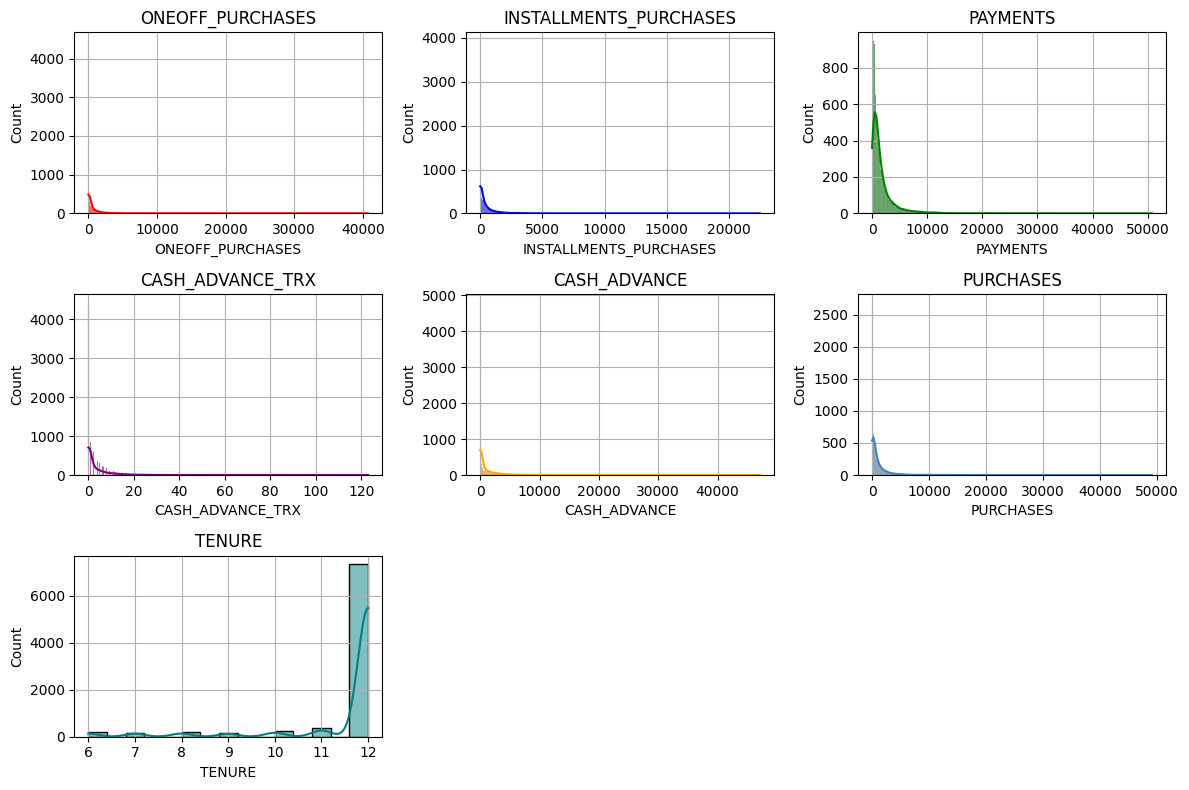

In [272]:
# Visualize all the columns with high skew to confirm skewness 

selected_cols = ['ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'PAYMENTS', 'CASH_ADVANCE_TRX', 'CASH_ADVANCE', 'PURCHASES', 'TENURE']
colors = ['red', 'blue', 'green', 'purple', 'orange', 'steelblue', 'teal']

fig, ax = plt.subplots(3, 3, figsize=(12, 8))

for idx, col in enumerate(selected_cols):
    r = idx // 3
    c = idx % 3

    sns.histplot(data=df, x=col, kde=True, color=colors[idx], ax = ax[r][c])
    ax[r][c].set_title(col) 
    ax[r][c].grid(True)

plt.delaxes(ax[2][1])
plt.delaxes(ax[2][2])
plt.tight_layout()
plt.show()   

**CONFIRMED: Most of the features have extreme skew**

In [273]:
# Log transform all columns which have a high skew (left & right)

right_skewed_cols = []
left_skewed_cols = []

for col in df.columns:
    if df[col].skew() > 1:
        right_skewed_cols.append(col)
    elif df[col].skew() < -1:
        left_skewed_cols.append(col)

# NOTE: If we log right skewed columns then they get even more right skewed so we reflect them first and then transform

for col in right_skewed_cols:
    df[col] = np.log1p(df[col])

for col in left_skewed_cols:
    max_val = df[col].max()
    df[col] = np.log1p(max_val + 1 - df[col])

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.780158,4.568506,0.000000,4.568506,0.000000,0.166667,0.000000,0.083333,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,0.693147
1,8.071989,0.737599,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.223144,1.609438,0.000000,8.853808,8.319725,6.978531,0.200671,0.693147
2,7.822504,0.693147,6.651791,6.651791,0.000000,0.000000,1.000000,0.693147,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,0.693147
4,6.707735,0.693147,2.833213,2.833213,0.000000,0.000000,0.083333,0.080042,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,0.693147
5,7.501540,0.693147,7.196147,0.000000,7.196147,0.000000,0.666667,0.000000,0.583333,0.000000,0.000000,2.197225,7.496097,7.244983,7.786654,0.000000,0.693147


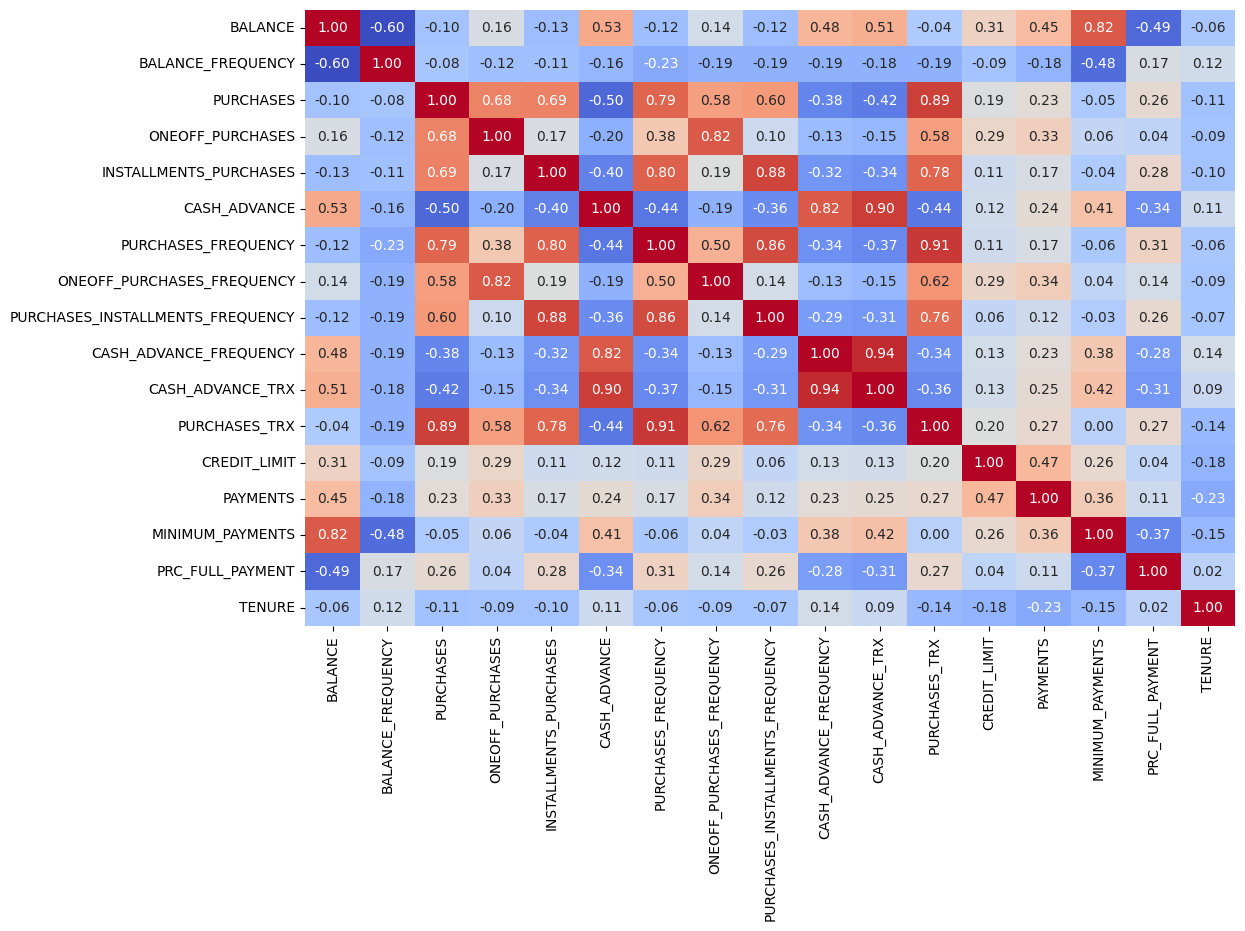

In [274]:
# Heatmap to detect colinearity

_corr = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(data=_corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
plt.show()

## Section II: Model Application

In [275]:
# Drop label

X = df.drop('TENURE', axis=1)
X.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
0,3.735304,0.780158,4.568506,0.000000,4.568506,0.000000,0.166667,0.000000,0.083333,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000
1,8.071989,0.737599,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.223144,1.609438,0.000000,8.853808,8.319725,6.978531,0.200671
2,7.822504,0.693147,6.651791,6.651791,0.000000,0.000000,1.000000,0.693147,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000
4,6.707735,0.693147,2.833213,2.833213,0.000000,0.000000,0.083333,0.080042,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000
5,7.501540,0.693147,7.196147,0.000000,7.196147,0.000000,0.666667,0.000000,0.583333,0.000000,0.000000,2.197225,7.496097,7.244983,7.786654,0.000000


**NOTE: There are no categorical columns, so we do not need to encode**

In [276]:
# Standard scale X 

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_scaled = ss.fit_transform(X)

In [277]:
# Apply PCA 

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

# pca.components_ gives the loadings for each column
loadings = pd.DataFrame(pca.components_, columns=X.columns, index=[f"PC{i+1}" for i in range(pca.n_components_)])

loadings.head(10)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
PC1,-0.141835,-0.006049,0.360322,0.207422,0.322443,-0.301185,0.362140,0.219053,0.308224,-0.266079,-0.283204,0.370251,0.042534,0.043451,-0.111684,0.184171
PC2,0.423388,-0.301189,0.138839,0.231973,0.085530,0.243180,0.130367,0.234261,0.081945,0.259395,0.267473,0.181373,0.260694,0.340066,0.372250,-0.134163
PC3,-0.058337,0.240520,0.084442,0.486385,-0.367465,-0.077682,-0.206145,0.437678,-0.450718,-0.090687,-0.096159,-0.052922,0.221401,0.145533,-0.152642,0.054849
PC4,-0.270161,0.372269,-0.011613,-0.115832,0.140265,0.252428,0.048610,-0.062996,0.112213,0.313116,0.303464,0.023545,0.260459,0.317740,-0.255126,0.497982
PC5,0.159476,-0.005268,-0.136882,-0.252265,0.028301,-0.215095,-0.148560,-0.252410,-0.017881,-0.342171,-0.316913,-0.145729,0.555498,0.341905,0.264175,0.158054
PC6,0.018636,-0.609084,-0.157892,-0.053760,-0.190761,-0.035211,0.029319,0.164806,-0.102389,-0.016485,-0.026722,-0.072598,-0.269498,0.086477,-0.032093,0.661303
PC7,-0.106942,-0.335215,-0.095078,-0.047272,-0.052160,0.003157,0.101509,0.099229,0.040057,0.124415,0.058630,-0.003914,0.653619,-0.571714,-0.257090,-0.036489
PC8,0.012708,0.279706,0.193809,0.071964,-0.008444,-0.040656,-0.032630,-0.044378,-0.113635,0.071230,0.075614,0.062771,0.016911,-0.501852,0.649399,0.415451
PC9,-0.000939,0.275224,-0.498717,-0.321912,-0.144112,0.152879,0.318248,0.571376,0.152113,-0.167990,-0.059602,0.068454,-0.027137,-0.027094,0.189373,-0.055516


In [278]:
# Custom K-means clustering (brute force)

def euclidean_distance(f1, f2):
    return np.sqrt(np.sum((f1 - f2)**2))

def custom_k_means(data: np.ndarray, k: int, epochs: int = 50):
    groups = [_+1 for _ in range(k)]
    sample_groups = {_:-1 for _ in range(data.shape[0])}
    centroids = None
    for i in range(epochs):
        if i == 0:
            random_idx = np.random.choice(data.shape[0], k, replace=False)
            centroids = data[random_idx]

            for j, x, in enumerate(data):
                distances = []
                for c in centroids:
                    distances.append(euclidean_distance(x, c))
                sample_groups[j] = groups[np.argmin(distances)]
        else:
            new_centroids = []

            for g in groups:
                samples = []
                for sample, grp in sample_groups.items():
                    if grp == g:
                        samples.append(data[sample])
                new_centroids.append(np.mean(samples, axis=0))
            
            new_centroids = np.array(new_centroids)

            if np.allclose(new_centroids, centroids):
                break
            centroids = new_centroids

            for j, x in enumerate(data):
                distances = []
                for c in centroids:
                    distances.append(euclidean_distance(x, c))
                sample_groups[j] = groups[np.argmin(distances)]

    return sample_groups, centroids

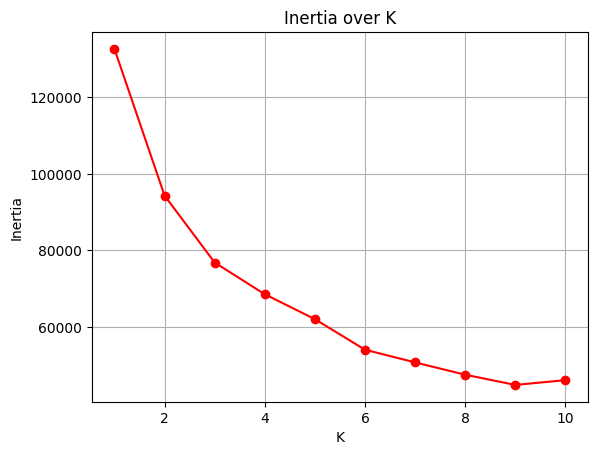

In [279]:
# Find the optimal value of k (custom implementation)

ks = [_ for _ in range(1, 11)]

inertias = []

for k in ks:
    inertia = 0
    sample_groups, centroids = custom_k_means(data=X_pca, k=k)
    for i, x in enumerate(X_pca):
        grp = sample_groups[i]
        c = centroids[grp - 1]
        inertia += np.linalg.norm(x - c)**2
    inertias.append(inertia)

plt.title('Inertia over K')
plt.plot(ks, inertias, color='red', marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

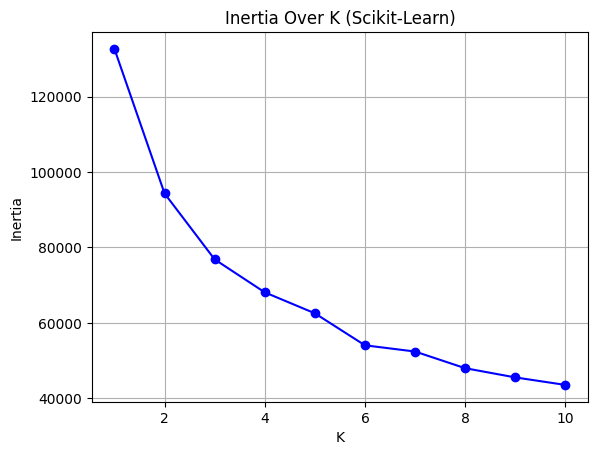

In [280]:
# Use the sklearn KMeans to find the optimal value of k

from sklearn.cluster import KMeans

inertias = []
ks = [k for k in range(1, 11)]

for k in ks:
    km = KMeans(n_clusters=k)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.plot(ks, inertias, color='blue', marker='o')
plt.title('Inertia Over K (Scikit-Learn)')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

**NOTE: The elbow plots for my implementation and the scikit-learn model are very similar - optimal value for 'k' in both seems to be 5**

In [281]:
sample_groups, _ = custom_k_means(data=X_pca, k=5)

pca_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]

cluster_samples = pd.DataFrame(X_pca, columns=pca_cols)
cluster_samples['CLUSTER'] = [sample_groups[i] for i in range(len(X_pca))]

cluster_samples.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,CLUSTER
0,-0.264012,-3.045114,-0.447847,-0.967622,-0.371661,-0.330583,-0.266598,-0.107415,-0.404476,5
1,-3.505184,0.902673,0.158851,1.001404,1.635003,0.594363,-0.308141,-0.155122,0.418379,2
2,1.424427,1.232765,2.285956,-1.834939,0.083021,0.268727,0.976640,0.202927,1.192681,1
3,-1.156336,-1.522215,0.588084,-1.846019,0.291403,0.727150,-0.582537,-0.615300,-0.295945,5
4,1.027705,0.335383,-1.861040,-1.427711,1.124764,-0.285593,-1.211716,0.408376,-0.212678,3


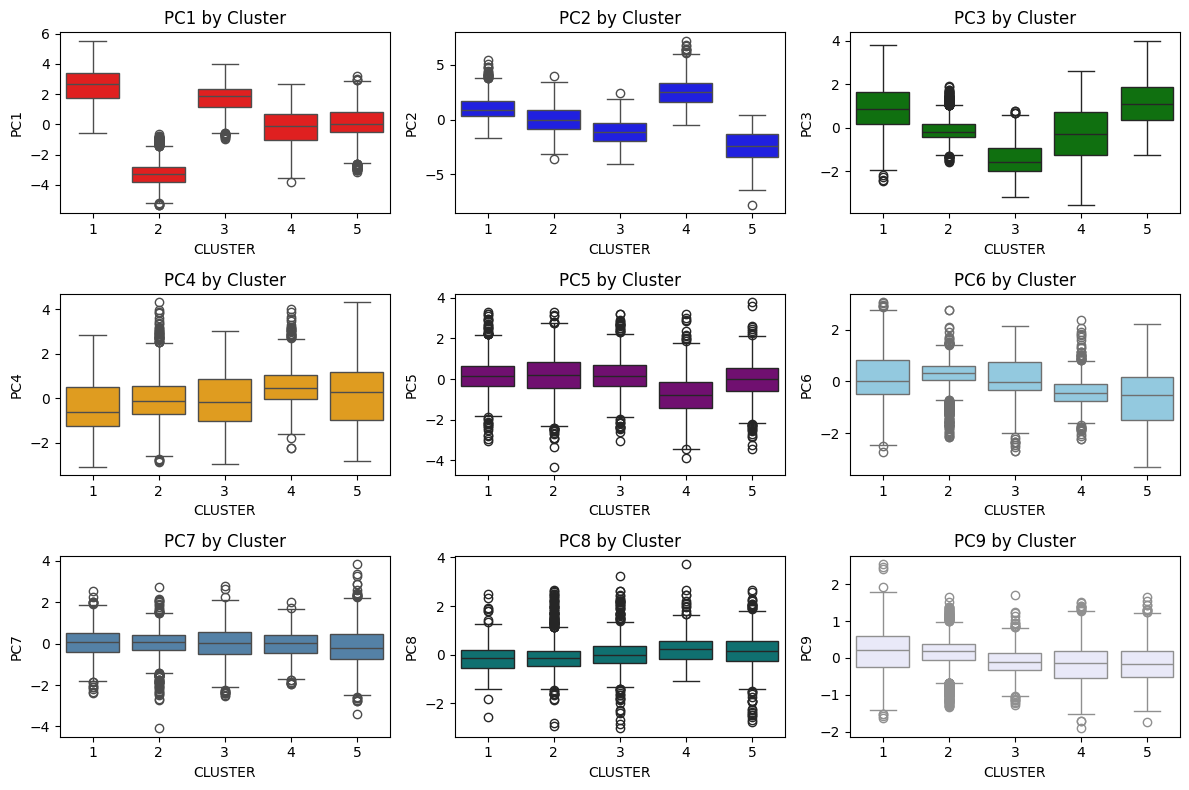

In [282]:
# See how different clusters differ by principal component

colors = ['red', 'blue', 'green', 'orange', 'purple', 'skyblue', 'steelblue', 'teal', 'lavender']
fig, ax = plt.subplots(3, 3, figsize=(12, 8))

for i in range(X_pca.shape[1]):
    r = i // 3
    c = i % 3

    sns.boxplot(data=cluster_samples, x='CLUSTER', y='PC'+str(i+1), color=colors[i], ax=ax[r][c])
    ax[r][c].set_title(f"PC{str(i + 1)} by Cluster")

plt.tight_layout()
plt.show()

In [283]:
# Remap clusters to original features

X_cols = X.columns
pca_cols = [c for c in cluster_samples.columns if c != 'CLUSTER']

X_reconstructed = cluster_samples[pca_cols].values @ loadings.values

clusters_to_X = pd.DataFrame(X_reconstructed, columns=X_cols)
clusters_to_X['CLUSTER'] = cluster_samples['CLUSTER'].values

In [ ]:
# Undo transformations

X_unscaled_log = ss.inverse_transform(clusters_to_X[X_cols].values)
clusters_to_X_untransformed = pd.DataFrame(X_unscaled_log, columns=X_cols)

for col in right_skewed_cols:
    clusters_to_X_untransformed[col] = np.expm1(clusters_to_X_untransformed[col])

for col in left_skewed_cols:
    if col == 'TENURE':
        continue
    max_val = df[col].max()  
    clusters_to_X_untransformed[col] = (max_val + 1) - np.expm1(clusters_to_X_untransformed[col])

clusters_to_X_untransformed['CLUSTER'] = clusters_to_X['CLUSTER'].values

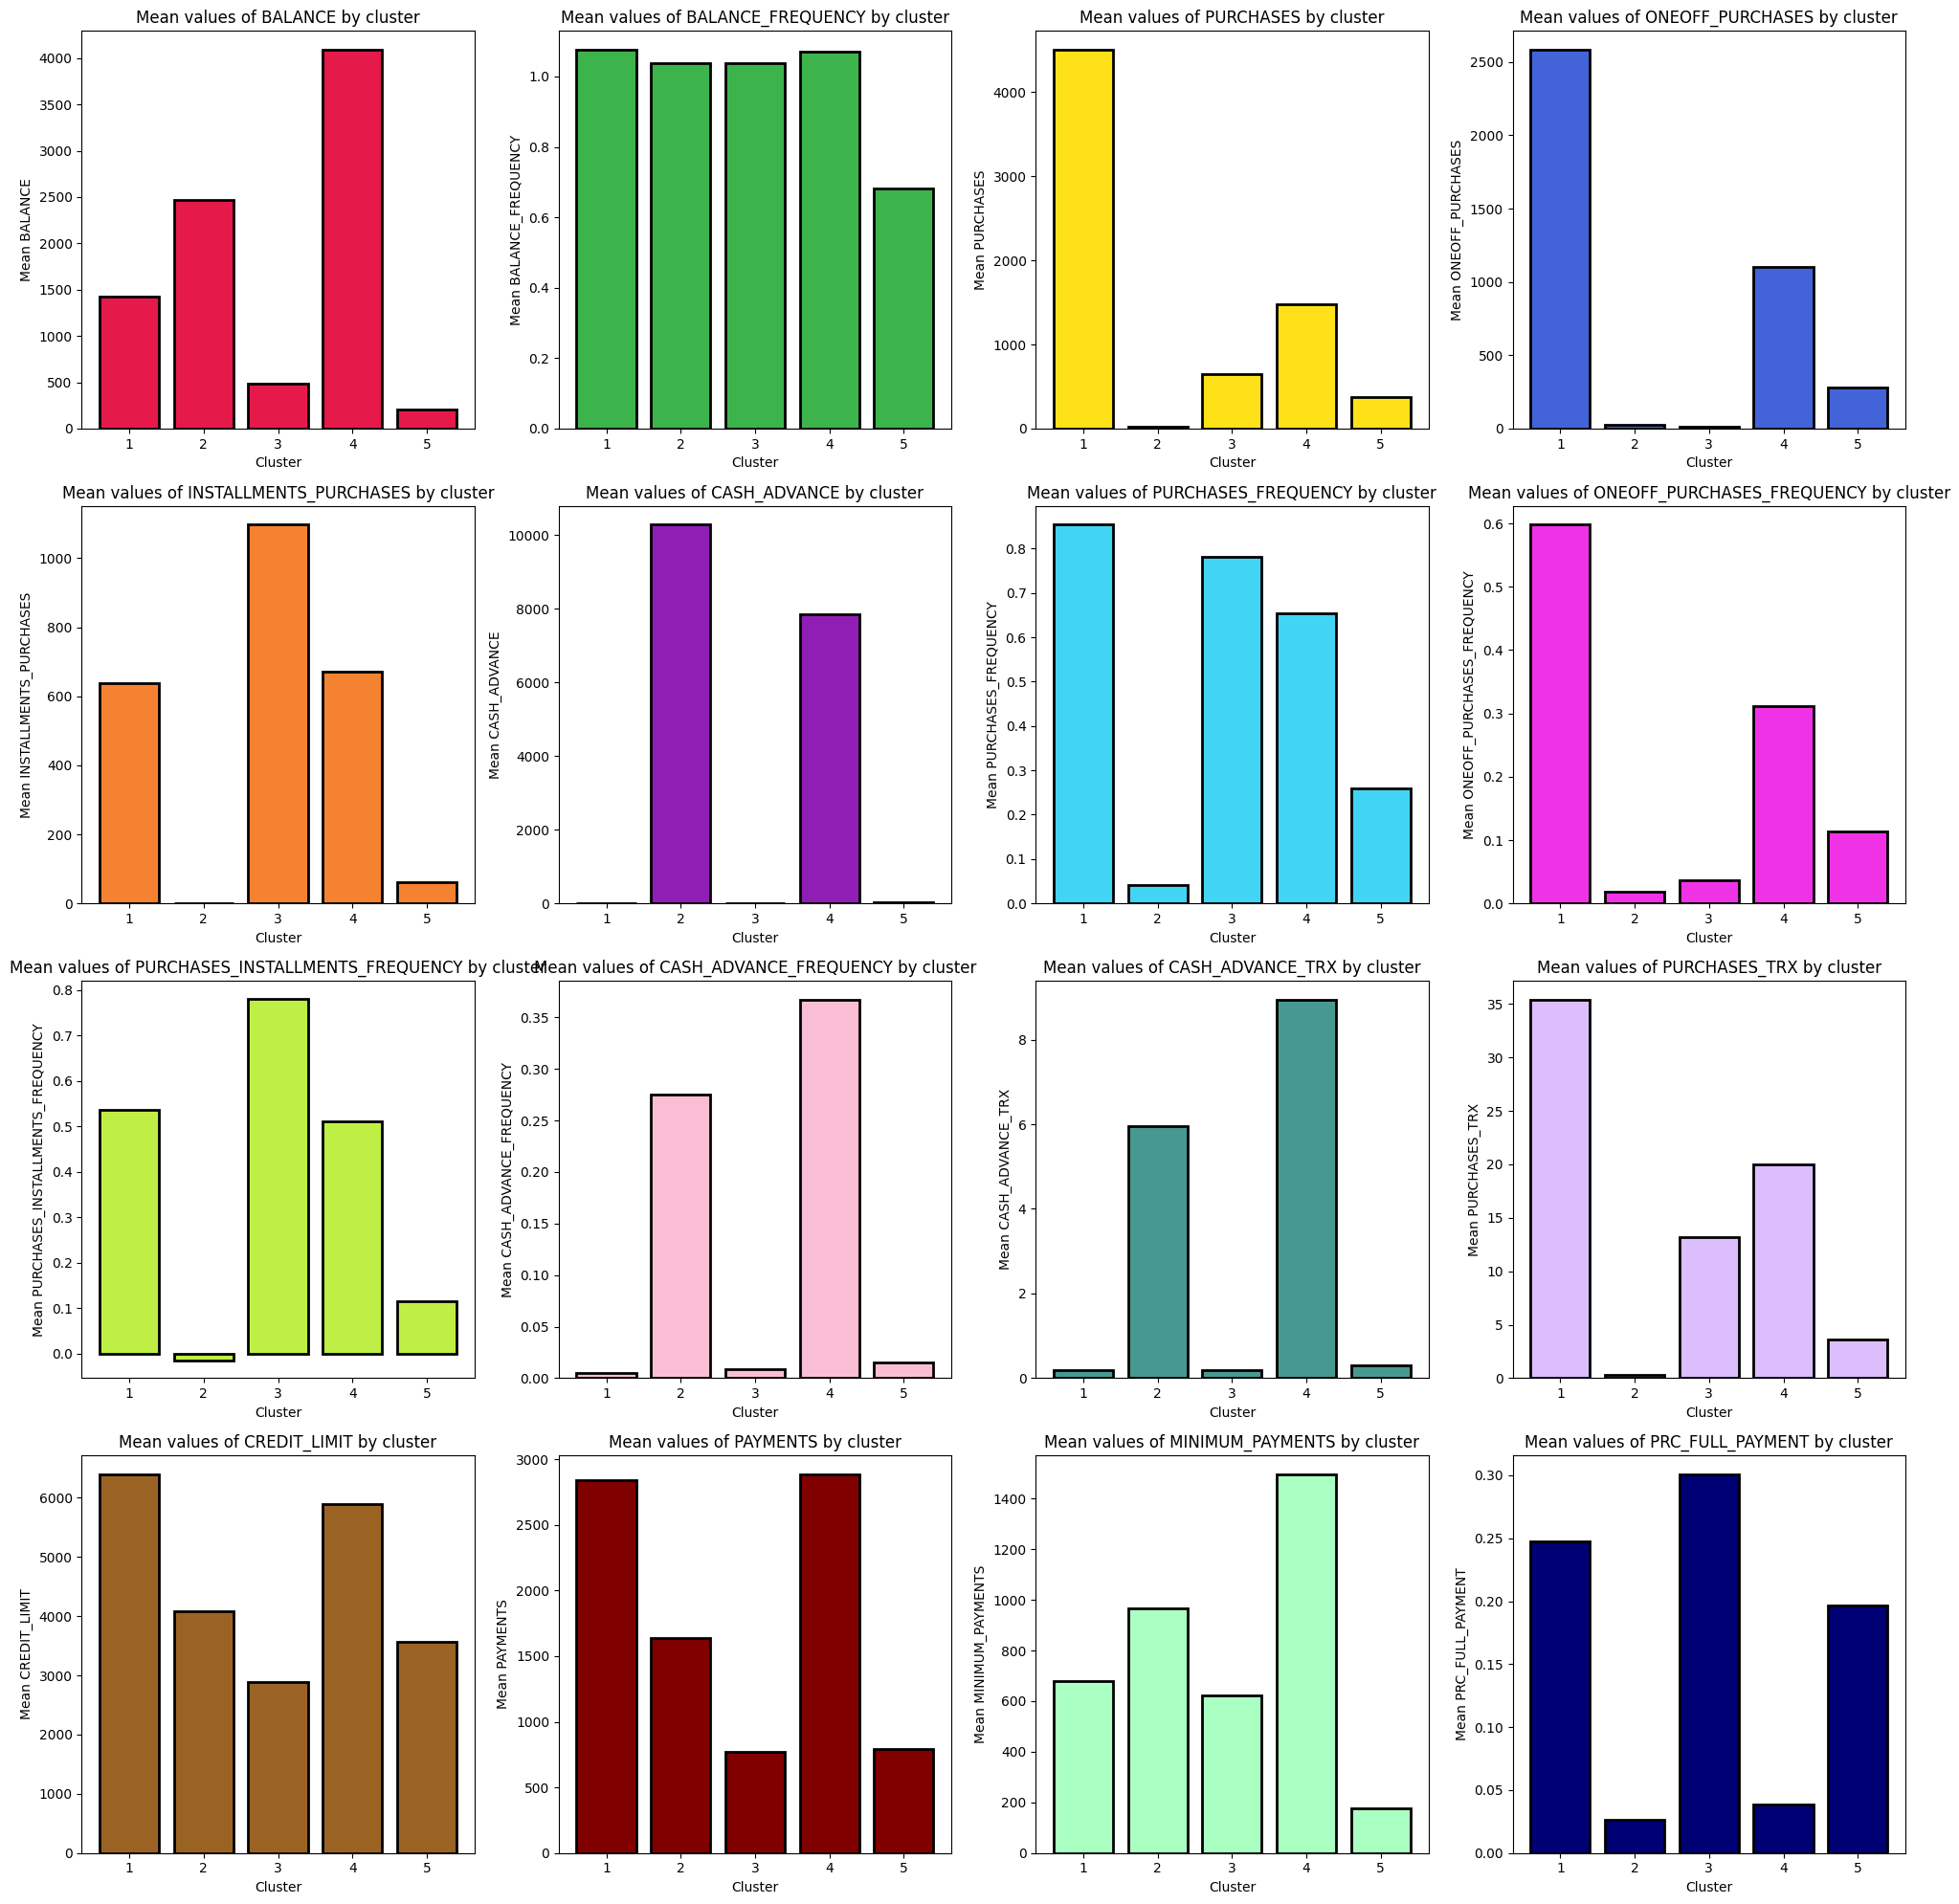

In [ ]:
# Mean metrics per cluster to identify group statistics

colors = [
    '#e6194B', '#3cb44b', '#ffe119', '#4363d8',
    '#f58231', '#911eb4', '#42d4f4', '#f032e6',
    '#bfef45', '#fabed4', '#469990', '#dcbeff',
    '#9A6324', '#800000', '#aaffc3', '#000075'
]

fig, ax = plt.subplots(4, 4, figsize=(20, 20))

selected_cols = clusters_to_X_untransformed.iloc[:, :-1].columns

for idx, col in enumerate(selected_cols):
    r = idx // 4
    c = idx % 4

    groupby_mean = clusters_to_X_untransformed.groupby('CLUSTER')[col].mean()
    ax[r][c].bar(groupby_mean.index, groupby_mean.values, color=colors[idx], edgecolor='black', linewidth=2)
    ax[r][c].set_title(f"Mean values of {col} by cluster")
    ax[r][c].set_xlabel('Cluster')
    ax[r][c].set_ylabel(f"Mean {col}")

plt.tight_layout()
plt.show()